In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/class.csv')
df = df[df['file'].str.contains('src/main/java', na=False)].copy()
print(df.shape)

(2152, 52)


In [5]:
import subprocess
import os

HUDI_REPO = '/tmp/hudi-check'

result = subprocess.run(
    ['git', 'log', 'release-0.13.0..release-0.14.0', '--name-only', '--pretty=format:%s'],
    cwd=HUDI_REPO, capture_output=True, text=True
)

buggy_files = set()
found = False
for line in result.stdout.split('\n'):
    if line == '':
        found = False
    elif line.startswith('[HUDI-') and ('fix' in line.lower() or 'bug' in line.lower()):
        found = True
    elif found and 'src/main/java' in line and line.endswith('.java'):
        buggy_files.add(line.split('/')[-1])

print(f'Buggy filenames found: {len(buggy_files)}')

Buggy filenames found: 261


In [6]:
df['filename'] = df['file'].apply(lambda p: p.split('/')[-1])
df['buggy'] = df['filename'].isin(buggy_files).astype(int)

print(df['buggy'].value_counts())
print(f"Positive rate: {df['buggy'].mean()*100:.1f}%")

buggy
0    1768
1     384
Name: count, dtype: int64
Positive rate: 17.8%


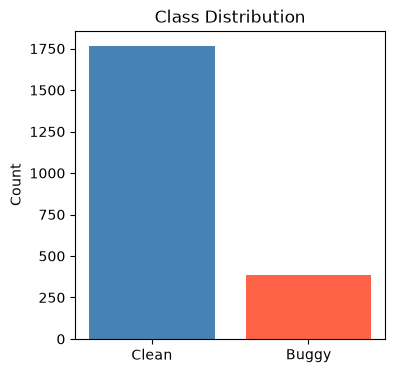

In [7]:
counts = df['buggy'].value_counts()
plt.figure(figsize=(4, 4))
plt.bar(['Clean', 'Buggy'], counts.values, color=['steelblue', 'tomato'])
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [8]:
FEATURES = ['cbo', 'wmc', 'rfc', 'fanin', 'fanout', 'dit', 'loc']

data = df[FEATURES + ['buggy']].dropna()

X = data[FEATURES].values
y = data['buggy'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (2152, 7)
y shape: (2152,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape} | Buggy in train: {y_train.sum()}')
print(f'Test set:     {X_test.shape}  | Buggy in test:  {y_test.sum()}')

Training set: (1721, 7) | Buggy in train: 307
Test set:     (431, 7)  | Buggy in test:  77


In [10]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

print('Done — means:', np.round(mu, 2))

Done — means: [ 8.   11.8  17.08  3.23  8.    1.58 55.66]


In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    f = sigmoid(X @ w + b)
    f = np.clip(f, 1e-10, 1 - 1e-10)
    cost = -(1/m) * np.sum(y * np.log(f) + (1-y) * np.log(1-f))
    return cost

In [13]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    f = sigmoid(X @ w + b)
    error = f - y
    dj_dw = (1/m) * (X.T @ error)
    dj_db = (1/m) * np.sum(error)
    return dj_dw, dj_db

In [14]:
def gradient_descent(X, y, alpha=0.1, num_iters=1000):
    n = X.shape[1]
    w = np.zeros(n)
    b = 0.0
    cost_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            cost_history.append(cost)
            print(f'Iteration {i}: Cost = {cost:.4f}')

    return w, b, cost_history

In [15]:
w, b, cost_history = gradient_descent(X_train_norm, y_train, alpha=0.1, num_iters=1000)

Iteration 0: Cost = 0.6791
Iteration 100: Cost = 0.4449
Iteration 200: Cost = 0.4380
Iteration 300: Cost = 0.4373
Iteration 400: Cost = 0.4372
Iteration 500: Cost = 0.4372
Iteration 600: Cost = 0.4372
Iteration 700: Cost = 0.4371
Iteration 800: Cost = 0.4371
Iteration 900: Cost = 0.4371


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_prob = sigmoid(X_test_norm @ w + b)
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Clean', 'Buggy']))

              precision    recall  f1-score   support

       Clean       0.84      0.99      0.91       354
       Buggy       0.67      0.10      0.18        77

    accuracy                           0.83       431
   macro avg       0.75      0.55      0.54       431
weighted avg       0.81      0.83      0.78       431



In [17]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
sk_model.fit(X_train_norm, y_train)
sk_pred = sk_model.predict(X_test_norm)

print(classification_report(y_test, sk_pred, target_names=['Clean', 'Buggy']))

              precision    recall  f1-score   support

       Clean       0.89      0.75      0.82       354
       Buggy       0.34      0.57      0.42        77

    accuracy                           0.72       431
   macro avg       0.61      0.66      0.62       431
weighted avg       0.79      0.72      0.75       431



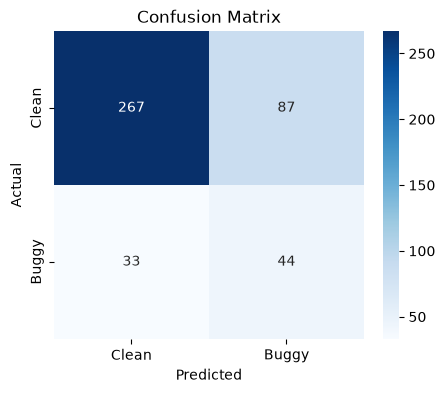

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, sk_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean', 'Buggy'],
            yticklabels=['Clean', 'Buggy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()